# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

#### Data problem definition

I would frame this as a regression problem. The outcome I want to explain is the price of a used car, and the input features are various attributes of the car, such as make, model, year, mileage, and condition, etc.

The idea is to try different models and select the one that explains the best the price of a used car.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

#### Data Exploration

First, we will explore the data to understand its structure and characteristics, available columns, missing values, and any potential outliers or anomalies that may impact our analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('data/vehicles.csv')
data.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [2]:
data.shape

(426880, 18)

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [4]:
missing_values = data.isna().mean().sort_values(ascending=False) * 100
missing_values

size            71.767476
cylinders       41.622470
condition       40.785232
VIN             37.725356
drive           30.586347
paint_color     30.501078
type            21.752717
manufacturer     4.133714
title_status     1.930753
model            1.236179
odometer         1.030735
fuel             0.705819
transmission     0.598763
year             0.282281
id               0.000000
region           0.000000
price            0.000000
state            0.000000
dtype: float64

In [5]:
data[['price', 'year', 'odometer']].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

,price,year,odometer
count,4.268800e+05,425675.000000,4.224800e+05
mean,7.519903e+04,2011.235191,9.804333e+04
std,1.218228e+07,9.452120,2.138815e+05
min,0.000000e+00,1900.000000,0.000000e+00
1%,0.000000e+00,1967.000000,2.000000e+00
5%,0.000000e+00,1998.000000,6.318000e+03
25%,5.900000e+03,2008.000000,3.770400e+04
50%,1.395000e+04,2013.000000,8.554800e+04
75%,2.648575e+04,2017.000000,1.335425e+05
95%,4.450000e+04,2020.000000,2.040000e+05


Based on the previous block, we can see that we are dealing with:

- A dataset with `426,880` observations and 18 columns
- The target variable we need is the price column
- Some columns have large number of missing values, like size, cylinders and condition
- There are cars with 0 miles and some cars with 0 price
- The maximum price in the set is `$3,736,929,000`  ($3.7 billion)

In [6]:
print("Rows with price <= 0:", (data['price'] <= 0).sum())
print("Rows with price > 100000:", (data['price'] > 100000).sum())
print("Rows with odometer <= 0:", (data['odometer'] <= 0).sum())
print("Rows with odometer > 300000:", (data['odometer'] > 300000).sum())
print("Duplicate ids:", data['id'].duplicated().sum())

Rows with price <= 0: 32895
Rows with price > 100000: 655
Rows with odometer <= 0: 1965
Rows with odometer > 300000: 3032
Duplicate ids: 0


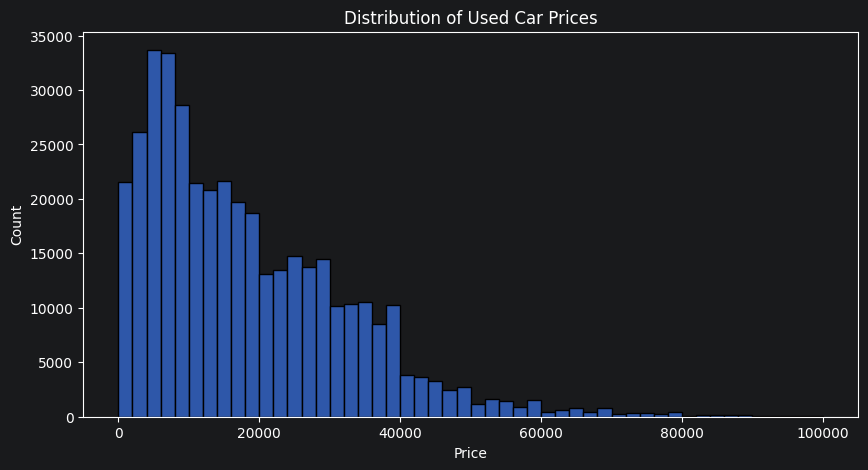

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(data[(data['price'] > 0) & (data['price'] < 100000)]['price'], bins=50)
plt.title('Distribution of Used Car Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

First we will remove observations to keep the dataset clean and realistic, we will keep observations:

- Price above `$1,000` and below `$100,000`
- Odometer above `1,000` and below `300,000`
- Year above `1990` and below `2022`

In [8]:
clean_data = data.copy()
clean_data = clean_data[(clean_data['price'] >= 1000) & (clean_data['price'] <= 100000)]
clean_data = clean_data[(clean_data['odometer'] >= 1000) & (clean_data['odometer'] <= 300000)]
clean_data = clean_data[(clean_data['year'] >= 1990) & (clean_data['year'] <= 2022)]
clean_data.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
27,7316814884,auburn,33590,2014.0,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923.0,clean,other,3GTP1VEC4EG551563,NaN,NaN,pickup,white,al
28,7316814758,auburn,22590,2010.0,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,other,1GCSCSE06AZ123805,NaN,NaN,pickup,blue,al
29,7316814989,auburn,39590,2020.0,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160.0,clean,other,3GCPWCED5LG130317,NaN,NaN,pickup,red,al
30,7316743432,auburn,30990,2017.0,toyota,tundra double cab sr,good,8 cylinders,gas,41124.0,clean,other,5TFRM5F17HX120972,NaN,NaN,pickup,red,al
31,7316356412,auburn,15000,2013.0,ford,f-150 xlt,excellent,6 cylinders,gas,128000.0,clean,automatic,NaN,rwd,full-size,truck,black,al


As we saw early, there are too many rows with missing values, if we drop all rows with missing values we will end with a dataset that is too small (30819 rows). As that would be too aggresive we will drop only the rows with missing values on a subset of columns:

Columns we don't want to be empty:
- `price`
- `odometer`
- `year`
- `condition`

In [9]:
required_columns = ['price', 'odometer', 'year', 'condition']
clean_data = clean_data.dropna(subset=required_columns)

clean_data[['price', 'year', 'odometer']].describe(
      percentiles=[.01, .05, .25, .5, .75, .95, .99]
  )

,price,year,odometer
count,222130.000000,222130.000000,222130.000000
mean,18538.944735,2012.050313,91949.742844
std,13095.520863,6.014767,63216.297586
min,1000.000000,1990.000000,1000.000000
1%,1500.000000,1994.000000,2408.000000
5%,3000.000000,2001.000000,9107.250000
25%,7500.000000,2008.000000,35200.000000
50%,15900.000000,2013.000000,85876.000000
75%,27590.000000,2017.000000,136599.000000
95%,40590.000000,2020.000000,204500.000000


We end with `222,130` observations

#### Correlation Between Numeric Variables

In [ ]:
corr_data = clean_data[['price', 'year', 'odometer']]

corr_matrix = corr_data.corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix,
  annot=True
)

plt.title('Correlation Between Numeric Variables')
plt.show()

#### Average price by condition and Average price by fuel type


In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
  data=clean_data,
  x='condition',
  y='price',
  estimator='mean',
  errorbar=None
)

plt.title('Average Price by Vehicle Condition')
plt.xlabel('Condition')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8, 5))

sns.barplot(
  data=clean_data,
  x='fuel',
  y='price',
  estimator='mean',
  errorbar=None
)

plt.title('Average Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=4)
plt.show()

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

#### Model 1 - Linear Regression Baseline

Use Linear Regression as a baseline model to establish a simple benchmark. The first model can use only numeric features such as `year` and `odometer`.
  After that, I can add categorical features such as `condition`, `transmission`, `fuel`, `title_status`, `paint_color`, and `state` using encoding.

##### Model 1.1 - Linear Regression using only numerical features

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Remove rows with empty data in any of the columns we want to use
model_data = clean_data[['price', 'year', 'odometer']].dropna()

X = model_data[['year', 'odometer']]
y = model_data['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Coef:", linear_model.coef_)

###### Linear regression prediction v/s Actual Cars

To visualize the linear regression model, I will compare the predicted prices against the actual car prices. As this model uses both `year` and `odometer`, I need to hold one variable constant in order to plot the relationship in two dimensions.

First, we fix `odometer` to its median value and vary `year` to show how the model predicts price changes across vehicle age.



In [ ]:
year_range = pd.DataFrame({
    'year': range(int(clean_data['year'].min()), int(clean_data['year'].max()) + 1),
    'odometer': clean_data['odometer'].median()
})

year_range['predicted_price'] = linear_model.predict(year_range)

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=clean_data.sample(5000, random_state=42),
    x='year',
    y='price',
    alpha=0.2,
    label='Actual cars'
)

plt.plot(
    year_range['year'],
    year_range['predicted_price'],
    color='red',
    linewidth=3,
    label='Model prediction at median odometer'
)

plt.title('Model 1.1: Predicted Price by Year')
plt.xlabel('Year')
plt.ylabel('Price')
plt.legend()
plt.show()


now, we fix `year` to its mean value and vary `odometer` to show how the model predicts price changes across vehicle mileage.


In [ ]:
mean_year = clean_data['year'].mean()

odometer_range = pd.DataFrame({
  'year': mean_year,
  'odometer': np.linspace(clean_data['odometer'].min(), clean_data['odometer'].max(), 100)
})

odometer_range['predicted_price'] = linear_model.predict(odometer_range)

plt.figure(figsize=(10, 5))
sns.scatterplot(
  data=clean_data.sample(5000, random_state=42),
  x='odometer',
  y='price',
  alpha=0.2,
  label='Actual cars'
)

plt.plot(
  odometer_range['odometer'],
  odometer_range['predicted_price'],
  color='red',
  linewidth=3,
  label=f'Model prediction at mean year ({mean_year:.0f})'
)

plt.title('Model 1.1: Predicted Price by Odometer')
plt.xlabel('Odometer')
plt.ylabel('Price')
plt.legend()
plt.show()

##### Model 1.2 - Linear Regression (categorical features)

Now we will extend our Linear Regression model (1.1) to also include five categorical features:

1. `condition`
2. `fuel`
3. `transmission`
4. `manufacturer`
5. `state`

To make use of these categorical features, we will encode them by using dummy variables.

In [ ]:
model_data_cat = clean_data[
      ['price', 'year', 'odometer', 'condition', 'fuel', 'transmission', 'manufacturer', 'state']
].dropna()

X = model_data_cat.drop(columns='price')
y = model_data_cat['price']

X_encoded = pd.get_dummies(X, columns=['condition', 'fuel', 'transmission', 'manufacturer', 'state'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

linear_model_cat = LinearRegression()
linear_model_cat.fit(X_train, y_train)

y_pred_cat = linear_model_cat.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_cat))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_cat)))

#### Model 2 - Polynomial Features + Linear Regression

Use Linear Regression with polynomial features to capture possible non-linear relationships between numeric features and price. For example, the relationship between mileage and price may not be perfectly linear.

To do so, we will use a degree of 2 polynomial features, to end with 5 features: `year`, `odometer`, `year^2`, `year odometer`, `odometer^2`.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

model_data_poly = clean_data[['price', 'year', 'odometer']].dropna()

X = model_data_poly[['year', 'odometer']]
y = model_data_poly['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

poly_model = Pipeline([
  ('quad_features', PolynomialFeatures(degree=2, include_bias=False)),
  ('quad_model', LinearRegression())
])

poly_model.fit(X_train, y_train)
y_pred_poly = poly_model.predict(X_test)

poly_features = poly_model.named_steps['quad_features']
print("Features:", poly_features.get_feature_names_out(['year', 'odometer']))

print("MAE:", mean_absolute_error(y_test, y_pred_poly))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_poly)))

#### Model 3 - Ridge Regression With Cross-Validation

For Model 3, I will use Ridge Regression with cross-validation. Ridge is a regularized version of linear regression that penalizes very large coefficients, which can help when the model includes multiple dummy-encoded categorical features. To do so, I will use a pipeline with
  `StandardScaler` and `Ridge`, then use `GridSearchCV` to compare several alpha values.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

model_data_ridge = clean_data[['price', 'year', 'odometer', 'condition', 'fuel', 'transmission', 'manufacturer', 'state']].dropna()

X = model_data_ridge.drop(columns='price')
y = model_data_ridge['price']

X_encoded = pd.get_dummies(X,columns=['condition', 'fuel', 'transmission', 'manufacturer', 'state'],drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

ridge_pipe = Pipeline([('scaler', StandardScaler()),('ridge', Ridge())])

params = { 'ridge__alpha': [0.1, 1, 10, 100, 1000] }

ridge_grid = GridSearchCV(ridge_pipe, param_grid=params, scoring='neg_mean_squared_error', cv=5)

ridge_grid.fit(X_train, y_train)

y_pred_ridge = ridge_grid.predict(X_test)

print("Best alpha:", ridge_grid.best_params_)
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

#### Model 4 - Ridge Regression With Sequential Feature Selection

First we will use a sample of the training data to select the features, once the features are selected we will use the full training data to train the model.


In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector

selection_sample_size = min(5000, len(X_train))

X_select = X_train.sample(selection_sample_size, random_state=42)
y_select = y_train.loc[X_select.index]

sfs_base_model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=10))
])

sfs = SequentialFeatureSelector(
    sfs_base_model,
    n_features_to_select=15,
    direction='forward',
    scoring='neg_mean_squared_error',
    cv=3,
    n_jobs=-1
)

sfs.fit(X_select, y_select)

selected_features = list(X_train.columns[sfs.get_support()])
selected_features

Now that we have 15 selected features, we can use these features to train a Ridge regression model on the full training set.

In [ ]:
sfs_ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=10))
])

sfs_ridge_model.fit(X_train[selected_features], y_train)
y_pred_sfs = sfs_ridge_model.predict(X_test[selected_features])

print('Selected feature count:', len(selected_features))
print('Selected features:', selected_features)
print('SFS Ridge MAE:', mean_absolute_error(y_test, y_pred_sfs))
print('SFS Ridge RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_sfs)))

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

#### Model Comparison

| Model     | Features                                           | MAE ($)     | RMSE (`$`)  |
|-----------|----------------------------------------------------|-------------|-------------|
| Model 1.1 | `year`, `odometer`                                 | `$7,178.97` | `$9,571.55` |
| Model 1.2 | numeric + categorical features                     | `$5,577.64` | `$7,620.35` |
| Model 2   | polynomial numeric features                        | `$6,707.23` | `$9,263.28` |
| Model 3   | Ridge regression with cross-validation             | `$5,577.61` | `$7,620.31` |
| Model 4   | Ridge regression with sequential feature selection | `$5,920.68` | `$8,006.36` |

Lower MAE and RMSE values are better, we can see from the table that Model 1.2 and Model 3 are the best models, Model 1.2 predicted price is `$5,577.64` away from the actual price (based on Mean Absolute Error) and Model 3 is `$5,577.61` away from the actual price (also based on Mean Absolute Error).

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

#### Final Report

The goal of this analysis was to understand which vehicle characteristics help explain used car prices and to build a model that can support pricing decisions for used car dealers.

After cleaning the data and testing several regression models, the best results came from models that included both numeric and categorical vehicle features. The first simple model used only `year` and `odometer`, but its prediction error was higher. When categorical features such as `condition`, `fuel`,
`transmission`, `manufacturer`, and `state` were added, the model improved noticeably.

Two of our five analyzed models performed the best. Since their results are almost identical, we will use the simpler one. It predicts used car prices with an average error of about $5,578.

This model could be used as a starting point when deciding how to price cars, it should be considered as another piece of information that can help to identify if a listing price might be too high or too low compared with similar listing, not as a final price. The model should support business judgment, not replace it.

The next step would be to retrain the model with more recent listing data and review which features have the strongest impact on price. This would help dealers better understand which types of vehicles are likely to command higher prices. From a model design perspective, the model could also be extended and tested with more features. The current models use `year`, `odometer`, `condition`, `fuel`, `transmission`, `manufacturer`, and `state`, but more features are available in the dataset.